In [1]:
# ============================================================
# Block 1: Imports and configuration
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from itertools import combinations
import statsmodels.api as sm
from statsmodels.formula.api import ols
import warnings
warnings.filterwarnings('ignore')

# --- npj Digital Medicine figure style ---
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 8
plt.rcParams['axes.labelsize'] = 8
plt.rcParams['axes.titlesize'] = 9
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['axes.linewidth'] = 1.0

# Color palette
sig_color = '#185FA5'       # blue (significant)
nsig_color = '#888780'      # grey (not significant)
consumer_color = '#66C2A5'  # green (Set2, Consumer)
provider_color = '#FC8D62'  # orange (Set2, Provider)


def clean_label(s):
    """Replace underscores with spaces and capitalize the first letter."""
    return s.replace('_', ' ').capitalize()


# Canonical dimension order used across all figures and tables.
canonical_order = [
    'technical_stability',
    'usability',
    'health_information',
    'monetization',
    'user_engagement',
    'data_privacy',
]

In [2]:
date_str = "20250904"

In [3]:
# ============================================================
# Block 2: Data loading and preprocessing
# ============================================================
df_consumer = pd.read_csv('../outputs/anal_res_20250904/category1_2/scores_with_factors.csv')
df_provider = pd.read_csv('../outputs/anal_res_20250904/category2_2/scores_with_factors.csv')

In [4]:
df_consumer.columns

Index(['appID', 'rating', 'review', 'sentiment', 'pricing_and_ads',
       'health_education_quality', 'technical_stability', 'usability',
       'engagement_and_motivation', 'privacy_and_ethical_data_use'],
      dtype='object')

In [5]:
df_consumer.columns = ['appID', 'rating', 'review', 'sentiment', 'monetization',
                       'health_information', 'technical_stability', 'usability',
                       'user_engagement', 'data_privacy']
df_provider.columns = df_consumer.columns.tolist()

feature_columns = ['technical_stability', 'usability', 'health_information',
                   'monetization', 'user_engagement', 'data_privacy']


def prepare_data(df):
    """Rescale dimension scores from [-1, 1] to [0, 1] and drop missing rows."""
    X = df[feature_columns].copy()
    X = (X + 1) / 2
    y = df['rating'].copy()
    mask = X.notna().all(axis=1) & y.notna()
    return X[mask], y[mask]


X_consumer, y_consumer = prepare_data(df_consumer)
X_provider, y_provider = prepare_data(df_provider)

print(f"Consumer-targeted apps:  n = {len(X_consumer):>6,} reviews")
print(f"Provider-targeted apps:  n = {len(X_provider):>6,} reviews")

Consumer-targeted apps:  n = 18,929 reviews
Provider-targeted apps:  n =  6,085 reviews


In [6]:
X_consumer

,technical_stability,usability,health_information,monetization,user_engagement,data_privacy
0,0.502703,0.500233,0.544739,0.505364,0.502413,0.500022
1,0.500033,0.500100,0.550480,0.499997,0.499388,0.500086
2,0.500039,0.500082,0.599664,0.500023,0.510965,0.499982
3,0.500012,0.500688,0.503931,0.500783,0.514932,0.500046
4,0.500101,0.500086,0.503103,0.500001,0.708824,0.499964
...,...,...,...,...,...,...
18924,0.500009,0.499950,0.500318,0.495554,0.499302,0.500002
18925,0.498197,0.107524,0.500093,0.499990,0.499039,0.499270
18926,0.147727,0.498786,0.499796,0.499970,0.498660,0.499984
18927,0.499994,0.001350,0.486894,0.499861,0.497569,0.516505


In [7]:
# ============================================================
# Block 3: Sample characteristics for Figure 1 - printed summary
# ============================================================
print("=" * 60)
print("Rating distribution by group (%)")
print("=" * 60)

consumer_ratings = df_consumer['rating'].dropna()
provider_ratings = df_provider['rating'].dropna()
ratings = [1, 2, 3, 4, 5]

consumer_pct = [(consumer_ratings == r).sum() / len(consumer_ratings) * 100 for r in ratings]
provider_pct = [(provider_ratings == r).sum() / len(provider_ratings) * 100 for r in ratings]

print(f"{'Rating':<10}{'Consumer':>14}{'Provider':>14}")
print("-" * 60)
for r, c_pct, p_pct in zip(ratings, consumer_pct, provider_pct):
    print(f"{r:<10}{c_pct:>13.2f}%{p_pct:>13.2f}%")
print("-" * 60)
print(f"{'n':<10}{len(consumer_ratings):>14,}{len(provider_ratings):>14,}")
print(f"{'Mean':<10}{consumer_ratings.mean():>14.2f}{provider_ratings.mean():>14.2f}")
print("=" * 60)

print("\n" + "=" * 60)
print("Mean dimension scores by group")
print("=" * 60)
print(f"{'Dimension':<25}{'Consumer':>15}{'Provider':>15}")
print("-" * 60)
for col in feature_columns:
    c_mean = df_consumer[col].mean()
    p_mean = df_provider[col].mean()
    print(f"{clean_label(col):<25}{c_mean:>15.4f}{p_mean:>15.4f}")
print("=" * 60)

Rating distribution by group (%)
Rating          Consumer      Provider
------------------------------------------------------------
1                 25.69%        17.47%
2                  6.00%         4.08%
3                  6.23%         5.70%
4                  9.25%        10.98%
5                 52.84%        61.77%
------------------------------------------------------------
n                 18,929         6,085
Mean                3.58          3.96

Mean dimension scores by group
Dimension                       Consumer       Provider
------------------------------------------------------------
Technical stability              -0.0170        -0.0237
Usability                         0.0047         0.0174
Health information                0.0113         0.0290
Monetization                     -0.0017        -0.0009
User engagement                   0.0091        -0.0074
Data privacy                     -0.0126        -0.0030


In [8]:
df_provider[['rating']].value_counts()

rating
5         3759
1         1063
4          668
3          347
2          248
Name: count, dtype: int64

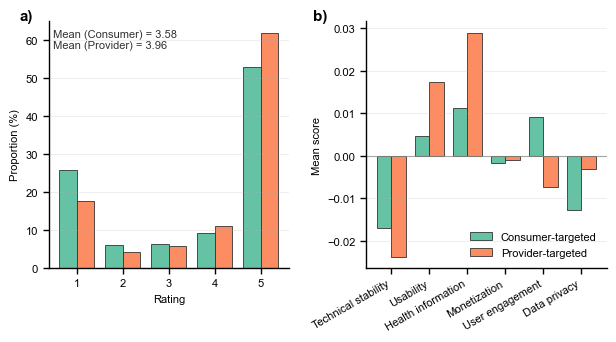

In [9]:
# ============================================================
# Block 4: Figure 1
# Panel a: rating distribution by group (grouped histogram, %).
# Panel b: mean dimension scores by group.
# ============================================================
clean_dim_labels = [clean_label(c) for c in feature_columns]

fig1, axes1 = plt.subplots(1, 2, figsize=(7.2, 3.2))
plt.subplots_adjust(wspace=0.32)

# (a) Rating distribution by group - grouped histogram (%)
ax_a = axes1[0]

x_pos_a = np.arange(len(ratings))
bar_width = 0.38

ax_a.bar(x_pos_a - bar_width/2, consumer_pct, bar_width,
         color=consumer_color, edgecolor='#333333', linewidth=0.6,
         label='Consumer-targeted')
ax_a.bar(x_pos_a + bar_width/2, provider_pct, bar_width,
         color=provider_color, edgecolor='#333333', linewidth=0.6,
         label='Provider-targeted')

mean_consumer = consumer_ratings.mean()
mean_provider = provider_ratings.mean()
ax_a.text(0.02, 0.97,
          f'Mean (Consumer) = {mean_consumer:.2f}\nMean (Provider) = {mean_provider:.2f}',
          transform=ax_a.transAxes, fontsize=8, color='#333333',
          va='top', ha='left')

ax_a.set_xticks(x_pos_a)
ax_a.set_xticklabels(['1', '2', '3', '4', '5'])
ax_a.set_xlabel('Rating')
ax_a.set_ylabel('Proportion (%)')

ax_a.tick_params(axis='x', length=4, width=1, direction='out',
                 bottom=True, top=False)
ax_a.tick_params(axis='y', length=4, width=1, direction='out',
                 left=True, right=False)
ax_a.spines['top'].set_visible(False)
ax_a.spines['right'].set_visible(False)
ax_a.grid(axis='y', alpha=0.2)

# (b) Mean dimension scores by group
ax_b = axes1[1]
mean_consumer_dim = [df_consumer[col].mean() for col in feature_columns]
mean_provider_dim = [df_provider[col].mean() for col in feature_columns]

x_pos = np.arange(len(feature_columns))
width = 0.38

ax_b.bar(x_pos - width/2, mean_consumer_dim, width,
         color=consumer_color, edgecolor='#333333', linewidth=0.6,
         label='Consumer-targeted')
ax_b.bar(x_pos + width/2, mean_provider_dim, width,
         color=provider_color, edgecolor='#333333', linewidth=0.6,
         label='Provider-targeted')

ax_b.axhline(y=0, color='#888780', linewidth=0.8, alpha=0.7)

ax_b.set_xticks(x_pos)
ax_b.set_xticklabels(clean_dim_labels, rotation=30, ha='right')
ax_b.set_ylabel('Mean score')
ax_b.set_xlabel('')

ax_b.tick_params(axis='x', length=4, width=1, direction='out',
                 bottom=True, top=False)
ax_b.tick_params(axis='y', length=4, width=1, direction='out',
                 left=True, right=False)
ax_b.spines['top'].set_visible(False)
ax_b.spines['right'].set_visible(False)
ax_b.grid(axis='y', alpha=0.2)
ax_b.legend(loc='lower right', frameon=False)

panel_label_kwargs = {'fontsize': 11, 'fontweight': 'bold', 'va': 'top'}
axes1[0].text(-0.12, 1.05, 'a)', transform=axes1[0].transAxes, **panel_label_kwargs)
axes1[1].text(-0.22, 1.05, 'b)', transform=axes1[1].transAxes, **panel_label_kwargs)

# plt.savefig('figure_1.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('figure_1.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
# ============================================================
# Block 5: Within-group standardization, interaction model, and
# Wald-based pairwise tests for Figure 2.
#
# Analytical decisions (revised 2026-06-01):
#   - Standard errors: classical OLS SE (no robust adjustment).
#     The analytic unit is the individual review; sensitivity
#     analyses with HC3 and cluster-robust SE are reported in
#     the Supplementary Information.
#   - Multiple-testing correction: raw (uncorrected) p-values
#     are reported as primary, following Rothman (1990) and
#     Perneger (1998); each comparison addresses a distinct,
#     pre-specified hypothesis about how factor weights differ
#     between user groups, and the global null hypothesis is
#     not of interest. Holm-Bonferroni-adjusted p-values are
#     reported alongside in parentheses for reviewer
#     transparency and as a more conservative sensitivity
#     check; Bonferroni values are also computed and reported
#     in the Supplementary Information.
#
# Inputs assumed from upstream blocks:
#   X_consumer, y_consumer, X_provider, y_provider, feature_columns
# ============================================================

from itertools import combinations
from statsmodels.stats.multitest import multipletests


# --- Within-group standardization (z-score) ---
def standardize_data(X, y):
    """Standardize X and y to z-scores within group."""
    X_std = (X - X.mean()) / X.std()
    y_std = (y - y.mean()) / y.std()
    return X_std, y_std


X_consumer_std, y_consumer_std = standardize_data(X_consumer, y_consumer)
X_provider_std, y_provider_std = standardize_data(X_provider, y_provider)


# --- Test 1: between-group differences in standardized betas (interaction model) ---
# Stack standardized data; fit a unified OLS with group-by-factor
# interactions. The interaction coefficient is the Provider - Consumer
# difference; group-specific betas are recovered from the same fit.
df_c_std = X_consumer_std.copy()
df_c_std['rating'] = y_consumer_std.values
df_c_std['group'] = 'consumer'

df_p_std = X_provider_std.copy()
df_p_std['rating'] = y_provider_std.values
df_p_std['group'] = 'provider'

df_combined_std = pd.concat([df_c_std, df_p_std], ignore_index=True)

main_terms = " + ".join(feature_columns)
inter_terms = " + ".join([f"C(group):{c}" for c in feature_columns])
formula = f"rating ~ {main_terms} + C(group) + {inter_terms}"

# Classical OLS SE (no robust adjustment).
inter_model_std = ols(formula, data=df_combined_std).fit()

# Interaction coefficients (Provider - Consumer, standardized units)
inter_rows = []
for c in feature_columns:
    key = f"C(group)[T.provider]:{c}"
    inter_rows.append({
        'Factor': c,
        'beta_diff (P-C)': inter_model_std.params[key],
        'std_err': inter_model_std.bse[key],
        't': inter_model_std.tvalues[key],
        'p': inter_model_std.pvalues[key],
        'CI_lower': inter_model_std.conf_int().loc[key, 0],
        'CI_upper': inter_model_std.conf_int().loc[key, 1],
        'sig (p<0.05)': 'Y' if inter_model_std.pvalues[key] < 0.05 else '',
    })
inter_df = pd.DataFrame(inter_rows)

print("=" * 70)
print("[Test 1] Between-group differences in standardized betas")
print("        Standard errors: classical OLS (no robust adjustment)")
print("        Multiple-testing correction: none (pre-specified hypotheses)")
print("=" * 70)
print(inter_model_std.summary())
print("\nProvider - Consumer differences (standardized units):")
print(inter_df.round(4).to_string(index=False))


# --- Recover group-specific betas from the interaction model ---
def extract_group_betas_from_interaction(model, factors):
    """
    Recover Consumer and Provider standardized betas (with 95% CIs)
    from the fitted interaction model.

    Consumer beta = main effect (consumer is the reference group)
    Provider beta = main effect + group-by-factor interaction

    CIs for the Provider sum are obtained via t_test, which accounts
    for the covariance between the two coefficients under the
    covariance specification used to fit the model.
    """
    rows_consumer = []
    rows_provider = []
    for c in factors:
        rows_consumer.append({
            'Factor': c,
            'beta': model.params[c],
            'CI_lower': model.conf_int().loc[c, 0],
            'CI_upper': model.conf_int().loc[c, 1],
        })
        contrast = f"{c} + C(group)[T.provider]:{c}"
        t_result = model.t_test(contrast)
        rows_provider.append({
            'Factor': c,
            'beta': float(t_result.effect[0]),
            'CI_lower': float(t_result.conf_int()[0, 0]),
            'CI_upper': float(t_result.conf_int()[0, 1]),
        })
    return pd.DataFrame(rows_consumer), pd.DataFrame(rows_provider)


beta_consumer_df, beta_provider_df = extract_group_betas_from_interaction(
    inter_model_std, feature_columns
)

print("\n" + "=" * 70)
print("Group-specific standardized betas (from the interaction model)")
print("=" * 70)
print("\nConsumer:")
print(beta_consumer_df.round(4).to_string(index=False))
print("\nProvider:")
print(beta_provider_df.round(4).to_string(index=False))


# --- Test 2: within-group pairwise differences in betas (Wald linear contrasts) ---
# For each group, fit a within-group OLS on standardized data and test
# all C(6, 2) = 15 factor-pair differences via Wald linear-contrast tests.
# Each test compares two coefficients while accounting for their covariance
# through the model's full covariance matrix.
#
# Standard errors: classical OLS (no robust adjustment).
# Reporting: raw p (primary); Holm-Bonferroni-adjusted p in parentheses
# for transparency; Bonferroni p in the Supplementary Information.

def pairwise_wald(X_std, y_std):
    """
    Pairwise Wald tests for differences between standardized betas in a
    single-group OLS fit on pre-standardized data, using classical SE.

    Returns
    -------
    pmat_raw : np.ndarray, shape (k, k)
        Symmetric matrix of raw two-sided p-values. Diagonal is NaN.
    pmat_holm : np.ndarray, shape (k, k)
        Symmetric matrix of Holm-Bonferroni-adjusted p-values
        (adjustment performed over the 15 within-group pairs).
    cols : list[str]
        Column order corresponding to the matrices.
    diff_rows : list[dict]
        Per-comparison details: estimate, 95% CI, t, raw p, Holm p,
        and Bonferroni p (the latter for Supplementary reporting).
    """
    X_const = sm.add_constant(X_std)
    model = sm.OLS(y_std, X_const).fit()

    cols = X_std.columns.tolist()
    k = len(cols)
    pmat_raw = np.full((k, k), np.nan)
    pmat_holm = np.full((k, k), np.nan)
    diff_rows = []
    raw_pvalues = []
    pair_indices = []

    for i, j in combinations(range(k), 2):
        contrast = f"{cols[i]} - {cols[j]} = 0"
        t_result = model.t_test(contrast)
        est = float(t_result.effect[0])
        se = float(t_result.sd[0, 0])
        t_stat = float(t_result.tvalue[0, 0])
        p_raw = float(t_result.pvalue)
        ci_low = float(t_result.conf_int()[0, 0])
        ci_high = float(t_result.conf_int()[0, 1])

        pmat_raw[i, j] = p_raw
        pmat_raw[j, i] = p_raw

        diff_rows.append({
            'Comparison': f"{cols[i]} vs {cols[j]}",
            'estimate': est,
            'std_err': se,
            'CI_lower': ci_low,
            'CI_upper': ci_high,
            't': t_stat,
            'p_raw': p_raw,
            'sig_raw': 'Y' if p_raw < 0.05 else '',
        })
        raw_pvalues.append(p_raw)
        pair_indices.append((i, j))

    # Holm-Bonferroni (reported alongside raw for transparency)
    _, p_holm, _, _ = multipletests(raw_pvalues, alpha=0.05, method='holm')
    # Bonferroni (Supplementary)
    _, p_bonf, _, _ = multipletests(raw_pvalues, alpha=0.05, method='bonferroni')

    for row, (i, j), p_h, p_b in zip(diff_rows, pair_indices, p_holm, p_bonf):
        row['p_Holm'] = float(p_h)
        row['p_Bonferroni (suppl.)'] = float(p_b)
        row['sig_Holm'] = 'Y' if p_h < 0.05 else ''
        pmat_holm[i, j] = float(p_h)
        pmat_holm[j, i] = float(p_h)

    return pmat_raw, pmat_holm, cols, diff_rows


pmat_c, pmat_holm_c, cols_c, diff_rows_c = pairwise_wald(X_consumer_std, y_consumer_std)
pmat_p, pmat_holm_p, cols_p, diff_rows_p = pairwise_wald(X_provider_std, y_provider_std)


def print_pairwise(diff_rows, group_name):
    print(f"\n--- {group_name} group: pairwise comparison of standardized betas ---")
    df_pair = pd.DataFrame(diff_rows)
    df_pair = df_pair[['Comparison', 'estimate', 'std_err',
                       'CI_lower', 'CI_upper', 't',
                       'p_raw', 'sig_raw',
                       'p_Holm', 'sig_Holm',
                       'p_Bonferroni (suppl.)']]
    print(df_pair.round(4).to_string(index=False))
    return df_pair


print("\n" + "=" * 70)
print("[Test 2] Within-group pairwise differences in standardized betas")
print("        Wald linear-contrast tests on the within-group OLS fit.")
print("        Classical OLS SE.")
print("        Reporting: raw p (primary) and Holm-Bonferroni p")
print("        (reported alongside). Bonferroni p in Supplementary.")
print("=" * 70)

pair_consumer = print_pairwise(diff_rows_c, "Consumer")
pair_provider = print_pairwise(diff_rows_p, "Provider")

[Test 1] Between-group differences in standardized betas
        Standard errors: classical OLS (no robust adjustment)
        Multiple-testing correction: none (pre-specified hypotheses)
                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.221
Model:                            OLS   Adj. R-squared:                  0.220
Method:                 Least Squares   F-statistic:                     545.1
Date:                Thu, 02 Jul 2026   Prob (F-statistic):               0.00
Time:                        09:55:12   Log-Likelihood:                -32371.
No. Observations:               25014   AIC:                         6.477e+04
Df Residuals:                   25000   BIC:                         6.488e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                      

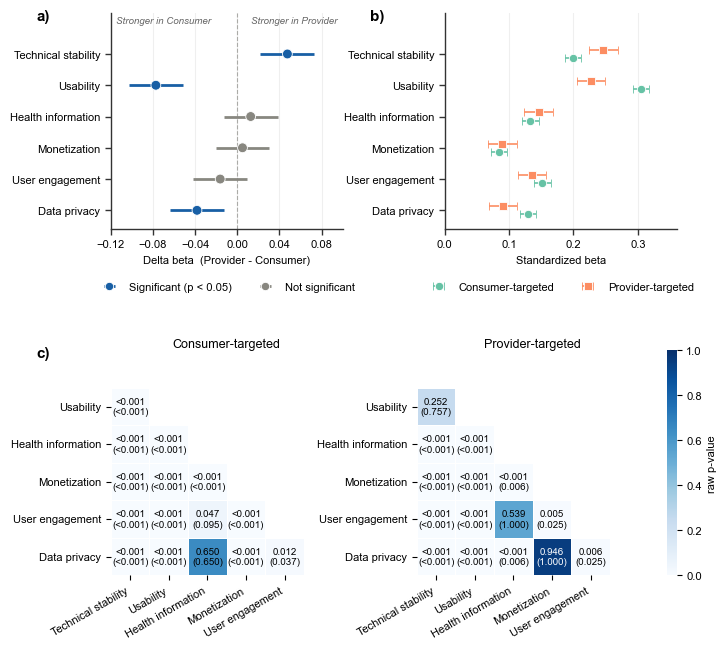

In [11]:
# ============================================================
# Block 6: Figure 3 — Statistical analysis results
#
# Three-panel visualization of the results from Block 5.
# All inferential statistics use classical OLS standard errors.
#
# Panel a: forest plot of between-group differences in standardized
#          betas (Provider - Consumer). Plots the interaction
#          coefficients from the unified OLS model with 95% CIs;
#          significance marked at uncorrected P < 0.05.
#
# Panel b: dot plot of group-specific standardized betas, recovered
#          from the same unified interaction model. Consumer beta
#          is the main effect (consumer is the reference category);
#          Provider beta is main effect plus the interaction term,
#          with CI computed via t_test contrast.
#
# Panel c: heatmap of within-group pairwise p-values from the
#          Wald linear-contrast tests. Each cell shows the raw
#          p-value with the Holm-Bonferroni-adjusted p-value in
#          parentheses immediately below. Heatmap shading reflects
#          the raw p-value.
# ============================================================
fig = plt.figure(figsize=(7.3, 7.3))
gs = fig.add_gridspec(
    nrows=2, ncols=21,
    height_ratios=[1.15, 1.2],
    hspace=0.55,
    wspace=2.0,
)

# (a) Forest plot - test 1
ax_a = fig.add_subplot(gs[0, 0:9])

inter_plot = inter_df.copy()
inter_plot = inter_plot.set_index('Factor').loc[canonical_order].reset_index()
inter_plot['Factor_label'] = inter_plot['Factor'].apply(clean_label)

y_pos = np.arange(len(inter_plot))[::-1]
colors_a = [sig_color if p < 0.05 else nsig_color for p in inter_plot['p']]

ax_a.axvline(x=0, color='#888780', linestyle='--', linewidth=0.8,
             alpha=0.7, zorder=1)
ax_a.hlines(
    y=y_pos,
    xmin=inter_plot['CI_lower'],
    xmax=inter_plot['CI_upper'],
    colors=colors_a,
    linewidth=2,
    zorder=2,
)
ax_a.scatter(
    inter_plot['beta_diff (P-C)'], y_pos,
    c=colors_a, s=50, zorder=3,
    edgecolors='white', linewidths=0.6,
)
ax_a.set_yticks(y_pos)
ax_a.set_yticklabels(inter_plot['Factor_label'])
ax_a.set_xlabel('Delta beta  (Provider - Consumer)')
ax_a.set_xlim(-0.12, 0.10)
ax_a.set_xticks(np.arange(-0.12, 0.11, 0.04))
ax_a.set_ylim(-0.6, len(inter_plot) - 0.5 + 0.8)

ax_a.tick_params(axis='x', which='major', length=4, width=1,
                 direction='out', bottom=True, top=False, color='#333333')
ax_a.tick_params(axis='y', which='major', length=4, width=1,
                 direction='out', left=True, right=False, color='#333333')
ax_a.grid(axis='x', alpha=0.2)
ax_a.spines['top'].set_visible(False)
ax_a.spines['right'].set_visible(False)
ax_a.spines['bottom'].set_color('#333333')
ax_a.spines['left'].set_color('#333333')

ax_a.text(-0.115, len(inter_plot) - 0.5 + 0.5, 'Stronger in Consumer',
          fontsize=7, style='italic', color='#666666', ha='left')
ax_a.text(0.095, len(inter_plot) - 0.5 + 0.5, 'Stronger in Provider',
          fontsize=7, style='italic', color='#666666', ha='right')

sig_handle = ax_a.errorbar([], [], xerr=[], fmt='o',
                            color=sig_color, markersize=6,
                            markeredgecolor='white', markeredgewidth=0.6,
                            capsize=3, capthick=1, elinewidth=2,
                            label='Significant (p < 0.05)')
nsig_handle = ax_a.errorbar([], [], xerr=[], fmt='o',
                             color=nsig_color, markersize=6,
                             markeredgecolor='white', markeredgewidth=0.6,
                             capsize=3, capthick=1, elinewidth=2,
                             label='Not significant')
ax_a.legend(handles=[sig_handle, nsig_handle],
            loc='upper center', bbox_to_anchor=(0.5, -0.20),
            ncol=2, frameon=False)

ax_a.text(-0.32, 1.02, 'a)', transform=ax_a.transAxes,
          fontsize=11, fontweight='bold', va='top')

# (b) Dot plot - group-specific betas recovered from the interaction model
ax_b = fig.add_subplot(gs[0, 12:21])

beta_consumer = beta_consumer_df.set_index('Factor').loc[canonical_order].reset_index()
beta_provider = beta_provider_df.set_index('Factor').loc[canonical_order].reset_index()

n_dim = len(canonical_order)
y_pos_b = np.arange(n_dim)[::-1]
offset = 0.13

ax_b.errorbar(
    beta_consumer['beta'],
    y_pos_b - offset,
    xerr=[beta_consumer['beta'] - beta_consumer['CI_lower'],
          beta_consumer['CI_upper'] - beta_consumer['beta']],
    fmt='o', color=consumer_color,
    markersize=6, markeredgecolor='white', markeredgewidth=0.6,
    capsize=3, capthick=1, elinewidth=1.2,
    label='Consumer-targeted',
)
ax_b.errorbar(
    beta_provider['beta'],
    y_pos_b + offset,
    xerr=[beta_provider['beta'] - beta_provider['CI_lower'],
          beta_provider['CI_upper'] - beta_provider['beta']],
    fmt='s', color=provider_color,
    markersize=6, markeredgecolor='white', markeredgewidth=0.6,
    capsize=3, capthick=1, elinewidth=1.2,
    label='Provider-targeted',
)

ax_b.set_yticks(y_pos_b)
ax_b.set_yticklabels([clean_label(d) for d in canonical_order])
ax_b.set_xlabel('Standardized beta')
ax_b.set_xlim(0, 0.36)
ax_b.set_ylim(-0.6, n_dim - 0.5 + 0.8)

ax_b.tick_params(axis='x', which='major', length=4, width=1,
                 direction='out', bottom=True, top=False, color='#333333')
ax_b.tick_params(axis='y', which='major', length=4, width=1,
                 direction='out', left=True, right=False, color='#333333')
ax_b.grid(axis='x', alpha=0.2)
ax_b.spines['top'].set_visible(False)
ax_b.spines['right'].set_visible(False)
ax_b.spines['bottom'].set_color('#333333')
ax_b.spines['left'].set_color('#333333')

ax_b.legend(loc='upper center', bbox_to_anchor=(0.5, -0.20),
            ncol=2, frameon=False)

ax_b.text(-0.32, 1.02, 'b)', transform=ax_b.transAxes,
          fontsize=11, fontweight='bold', va='top')

# (c) heatmap of within-group pairwise p-values
#     Annotation format per cell:
#         raw p
#         (Holm-Bonferroni p)
#     Heatmap shading reflects the raw p-value.
ax_c1 = fig.add_subplot(gs[1, 0:9])
ax_c2 = fig.add_subplot(gs[1, 11:20])
cax = fig.add_subplot(gs[1, 20:21])


def format_pval(p):
    """Format a p-value for compact annotation."""
    if np.isnan(p):
        return ''
    if p < 0.001:
        return '<0.001'
    return f'{p:.3f}'


def build_annot(pmat_raw, pmat_holm):
    """
    Build a 2D array of strings shaped like pmat_raw, where each entry is:
        "<raw p>\n(<Holm p>)"
    Returns empty strings on the diagonal and masked (upper-triangular) cells.
    """
    k = pmat_raw.shape[0]
    annot = np.empty((k, k), dtype=object)
    for i in range(k):
        for j in range(k):
            if np.isnan(pmat_raw[i, j]):
                annot[i, j] = ''
            else:
                annot[i, j] = f"{format_pval(pmat_raw[i, j])}\n({format_pval(pmat_holm[i, j])})"
    return annot


annot_c = build_annot(pmat_c, pmat_holm_c)
annot_p = build_annot(pmat_p, pmat_holm_p)

heatmap_kwargs = {
    'cmap': 'Blues', #'Blues_r',
    'vmin': 0, 'vmax': 1.0,
    'annot_kws': {'size': 7, 'color': 'black'},
    'square': False,
    'linewidths': 0.6,
    'linecolor': 'white',
}

mask_c = np.triu(np.ones_like(pmat_c, dtype=bool))
sns.heatmap(
    pmat_c, mask=mask_c,
    xticklabels=[clean_label(c) for c in cols_c],
    yticklabels=[clean_label(c) for c in cols_c],
    annot=annot_c, fmt='',
    cbar=False,
    ax=ax_c1, **heatmap_kwargs
)
ax_c1.set_title('Consumer-targeted', fontsize=9, pad=-3)
ax_c1.set_xticks(np.arange(len(cols_c) - 1) + 0.5)
ax_c1.set_xticklabels(
    [clean_label(c) for c in cols_c[:-1]],
    rotation=30, ha='right'
)
ax_c1.set_yticks(np.arange(1, len(cols_c)) + 0.5)
ax_c1.set_yticklabels(
    [clean_label(c) for c in cols_c[1:]],
    rotation=0
)

mask_p = np.triu(np.ones_like(pmat_p, dtype=bool))
sns.heatmap(
    pmat_p, mask=mask_p,
    xticklabels=[clean_label(c) for c in cols_p],
    yticklabels=[clean_label(c) for c in cols_p],
    annot=annot_p, fmt='',
    cbar=True,
    cbar_ax=cax,
    cbar_kws={'label': 'raw p-value'},
    ax=ax_c2, **heatmap_kwargs
)
ax_c2.set_title('Provider-targeted', fontsize=9, pad=-3)
ax_c2.set_xticks(np.arange(len(cols_p) - 1) + 0.5)
ax_c2.set_xticklabels(
    [clean_label(c) for c in cols_p[:-1]],
    rotation=30, ha='right'
)
ax_c2.set_yticks(np.arange(1, len(cols_p)) + 0.5)
ax_c2.set_yticklabels(
    [clean_label(c) for c in cols_p[1:]],
    rotation=0
)

# Annotation text color: white when the shading is dark (small raw p)
for ax_heatmap in (ax_c1, ax_c2):
    for txt in ax_heatmap.texts:
        first_line = txt.get_text().split('\n')[0]
        try:
            # "<0.001" -> treat as a very small value for color logic
            value = 0.0005 if first_line.startswith('<') else float(first_line)
            if value > 0.7: # value < 0.3:
                txt.set_color('white')
        except ValueError:
            continue

ax_c1.text(-0.32, 1.02, 'c)', transform=ax_c1.transAxes,
           fontsize=11, fontweight='bold', va='top')

plt.tight_layout()

# plt.savefig('figure_2.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('figure_2.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# ============================================================
# Block 7: Bin-level aggregation for Figure 3 - printed summary.
# Bins use left-closed, right-open intervals [a, b). The last bin
# is widened by one ULP so that exact 1.0 values are included.
# ============================================================
bin_edges = [-1.0, -0.6, -0.2, 0.2, 0.6, np.nextafter(1.0, np.inf)]
bin_centers = [-0.8, -0.4, 0.0, 0.4, 0.8]
bin_labels = ['[-1.0, -0.6)', '[-0.6, -0.2)', '[-0.2, 0.2)', '[0.2, 0.6)', '[0.6, 1.0]']


def aggregate_by_bin(df, dim_col):
    """
    Return (means, counts) per sentiment-score bin for a single dimension.

    Bins are left-closed, right-open via pd.cut(right=False); the upper
    edge of the last bin is nudged so that exactly 1.0 is included.
    """
    binned = pd.cut(df[dim_col], bins=bin_edges, right=False,
                    labels=bin_labels)
    grouped = df.groupby(binned, observed=False)['rating']
    means = grouped.mean().reindex(bin_labels).tolist()
    counts = grouped.size().reindex(bin_labels).fillna(0).astype(int).tolist()
    return means, counts


# Build the bin-aggregation table and print a per-dimension summary.
bin_results = {}
for dim in feature_columns:
    c_means, c_counts = aggregate_by_bin(df_consumer, dim)
    p_means, p_counts = aggregate_by_bin(df_provider, dim)
    bin_results[dim] = {
        'consumer_means': c_means,
        'consumer_counts': c_counts,
        'provider_means': p_means,
        'provider_counts': p_counts,
    }

print("=" * 90)
print("Mean rating and review count per sentiment-score bin (left-closed, right-open)")
print("=" * 90)
for dim in feature_columns:
    r = bin_results[dim]
    print(f"\n--- {clean_label(dim)} ---")
    print(f"{'Bin':<16}{'Consumer mean':>16}{'Consumer n':>14}"
          f"{'Provider mean':>18}{'Provider n':>14}")
    print("-" * 90)
    for i, lab in enumerate(bin_labels):
        c_m = r['consumer_means'][i]
        p_m = r['provider_means'][i]
        c_m_str = f"{c_m:.3f}" if not np.isnan(c_m) else "NA"
        p_m_str = f"{p_m:.3f}" if not np.isnan(p_m) else "NA"
        print(f"{lab:<16}{c_m_str:>16}{r['consumer_counts'][i]:>14,}"
              f"{p_m_str:>18}{r['provider_counts'][i]:>14,}")
print("=" * 90)

Mean rating and review count per sentiment-score bin (left-closed, right-open)

--- Technical stability ---
Bin                Consumer mean    Consumer n     Provider mean    Provider n
------------------------------------------------------------------------------------------
[-1.0, -0.6)               1.656           471             1.715           165
[-0.6, -0.2)               1.586           128             2.000            40
[-0.2, 0.2)                3.626        18,126             4.028         5,845
[0.2, 0.6)                 4.566            53             4.143             7
[0.6, 1.0]                 4.808           151             4.714            28

--- Usability ---
Bin                Consumer mean    Consumer n     Provider mean    Provider n
------------------------------------------------------------------------------------------
[-1.0, -0.6)               1.764           945             1.855           145
[-0.6, -0.2)               2.027           374             

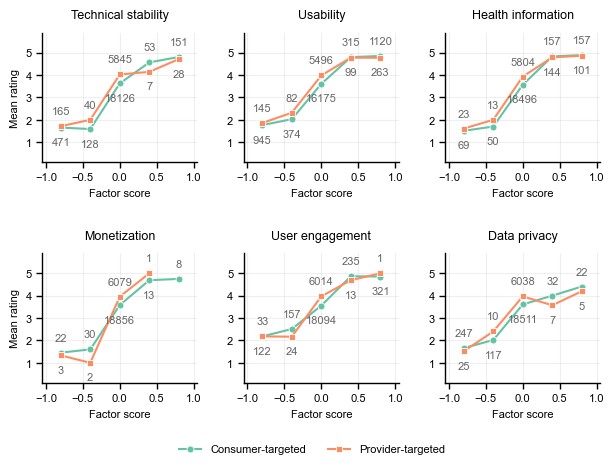

In [13]:
# ============================================================
# Block 8: Figure 3
# Sentiment threshold analysis by dimension.
# Six panels (3 columns x 2 rows), one per quality dimension. Each
# panel shows mean rating within bins of the dimension's sentiment-
# weighted score, separately for the two groups, with the bin count
# annotated next to each marker.
# ============================================================
fig3, axes3 = plt.subplots(2, 3, figsize=(7.2, 4.8), sharey=True)
plt.subplots_adjust(hspace=0.70, wspace=0.30)

LABEL_OFFSET = 7

for idx, dim in enumerate(feature_columns):
    row = idx // 3
    col = idx % 3
    ax = axes3[row, col]

    r = bin_results[dim]
    consumer_means = r['consumer_means']
    consumer_counts = r['consumer_counts']
    provider_means = r['provider_means']
    provider_counts = r['provider_counts']

    ax.plot(bin_centers, consumer_means, marker='o', markersize=5,
            color=consumer_color, linewidth=1.5,
            markeredgecolor='white', markeredgewidth=0.6,
            label='Consumer-targeted', zorder=3)
    ax.plot(bin_centers, provider_means, marker='s', markersize=5,
            color=provider_color, linewidth=1.5,
            markeredgecolor='white', markeredgewidth=0.6,
            label='Provider-targeted', zorder=3)

    # Place each count label on whichever side keeps the two group labels apart.
    for x, c_mean, c_n, p_mean, p_n in zip(
        bin_centers, consumer_means, consumer_counts,
        provider_means, provider_counts
    ):
        if not np.isnan(c_mean) and not np.isnan(p_mean):
            if c_mean >= p_mean:
                ax.annotate(f'{c_n}', xy=(x, c_mean), xytext=(0, LABEL_OFFSET),
                            textcoords='offset points',
                            fontsize=8, color='#666666', ha='center', va='bottom')
                ax.annotate(f'{p_n}', xy=(x, p_mean), xytext=(0, -LABEL_OFFSET),
                            textcoords='offset points',
                            fontsize=8, color='#666666', ha='center', va='top')
            else:
                ax.annotate(f'{p_n}', xy=(x, p_mean), xytext=(0, LABEL_OFFSET),
                            textcoords='offset points',
                            fontsize=8, color='#666666', ha='center', va='bottom')
                ax.annotate(f'{c_n}', xy=(x, c_mean), xytext=(0, -LABEL_OFFSET),
                            textcoords='offset points',
                            fontsize=8, color='#666666', ha='center', va='top')
        elif not np.isnan(c_mean):
            ax.annotate(f'{c_n}', xy=(x, c_mean), xytext=(0, LABEL_OFFSET),
                        textcoords='offset points',
                        fontsize=8, color='#666666', ha='center', va='bottom')
        elif not np.isnan(p_mean):
            ax.annotate(f'{p_n}', xy=(x, p_mean), xytext=(0, LABEL_OFFSET),
                        textcoords='offset points',
                        fontsize=8, color='#666666', ha='center', va='bottom')

    ax.set_title(clean_label(dim), fontsize=9, pad=10)
    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(0.1, 5.9)
    ax.set_xticks([-1, -0.5, 0, 0.5, 1])
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_xlabel('Factor score')

    if col == 0:
        ax.set_ylabel('Mean rating')

    ax.tick_params(axis='x', length=4, width=1, direction='out',
                   bottom=True, top=False)
    ax.tick_params(axis='y', length=4, width=1, direction='out',
                   left=True, right=False, labelleft=True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(alpha=0.2)

handles, labels = axes3[0, 0].get_legend_handles_labels()
fig3.legend(
    handles, labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    frameon=False,
    fontsize=8,
)
plt.subplots_adjust(bottom=0.15)

# plt.savefig('figure_3.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('figure_3.png', dpi=300, bbox_inches='tight')
plt.show()